# **Découverte des données**

In [5]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score, classification_report

df = pd.read_csv('./train_data_accidents.csv')



Nous allons tout d'abord supprimer les valeurs ne nous permettant pas de prédire quoi que ce soit, c'est-à-dire les personnes en fuite

In [6]:
df.drop(df.index[df['grav'] == -1], axis = 0, inplace = True)
df.drop(df.index[df['sexe'] == -1], axis = 0, inplace = True)
df.drop(df.index[df['place'] == -1], axis = 0, inplace = True)

Dans un premier temps, nous constatons que certaines valeurs de colonnes sont inutilisées / très peu représentées, nous avons donc décidés de les regrouper

<Axes: >

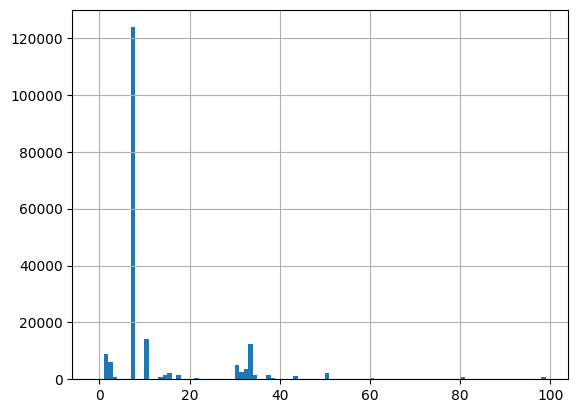

In [7]:
df['catv'].hist(bins = 100)

In [8]:
groupes_catv = {
    1: [1, 50, 60, 80], #vélos, hoverboard
    2: [2, 30, 4, 5, 6, 31, 32, 33, 34, 41, 42, 43, 35, 36], #les trucs de motos là
    4: [3, 7, 8, 9, 10, 11, 12], #Véhicules légers
    5: [13, 14, 15, 16, 17, 18, 19, 37, 38, 39, 40], #Gros poids lourd
    6: [20, 21, 0, 99] #Autres
}

for key, values in groupes_catv.items():
    df["catv"] = df["catv"].replace(values, key)


groupes_place = {
    2 : [2, 6],
    3 : [7, 8, 9],
    4 : [3, 4, 5]
}
for key, values in groupes_place.items():
    df["place"] = df["place"].replace(values, key)


groupes_undefined = {
    0 : [-1, 0]
}
for key, values in groupes_undefined.items():
    df["trajet"] = df["trajet"].replace(values, key)
    df["obs"] = df["obs"].replace(values, key)
    df['choc'] = df['choc'].replace(values, key)

groupes_obs = {
    3 : [3, 4, 5]
}
for key, values in groupes_obs.items():
    df["obs"] = df["obs"].replace(values, key)


groupes_obsm = {
    2 : [2, 4],
    5 : [5, 6]
}
for key, values in groupes_obsm.items():
  df["obsm"] = df["obsm"].replace(values, key)

groupe_choc = {
    1 : [1, 2, 3],
    4 : [4, 5, 6]
}
for key, values in groupe_choc.items():
  df["choc"] = df["choc"].replace(values, key)

groupes_manv = {
    11 : [11, 13, 15, 17],
    12 : [12, 14, 16, 18]
}
for key, values in groupes_manv.items():
  df["manv"].replace(values, key)

groupes_catr = {
    5 : [5, 6, 9]
}
for key, values in groupes_catr.items():
  df["catr"].replace(values, key)

groupes_surf = {
    3 : [3, 4, 5, 6, 7, 8, 9]
}
for key, values in groupes_surf.items():
  df["surf"].replace(values, key)

groupes_infra = {
    9 : [4, 6, 7, 8, 9]
}
for key, values in groupes_infra.items():
  df["infra"].replace(values, key)


<Axes: >

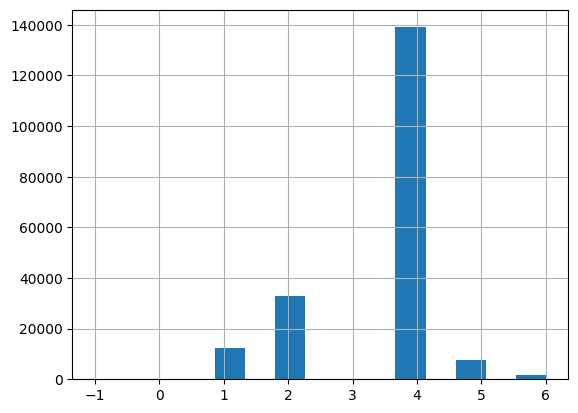

In [9]:
df['catv'].hist(bins = 15)

# **Parsing**

In [10]:
df['heure'] = df['hrmn'].str.split(':').str[0]

In [11]:
df = df.dropna(subset=['an_nais'])
df['age'] = 2021 - df['an_nais']

# **Regroupement**

In [12]:
df['is_protected'] = df[['secu1', 'secu2', 'secu3']].isin([1, 2, 3, 5, 6, 7]).any(axis=1).astype(int)
df.drop(columns=['jour', 'occutc', 'lat', 'long', 'hrmn', 'an_nais', 'secu1','secu2', 'secu3', 'vosp'], inplace=True)

On constate tout d'abord que certaines données sont inutilisables à cause de NaN à certains endroits

# **Nettoyage des données (suppression des NaN, données non renseignées etc.)**

In [13]:
df.drop(df.index[(df['obsm'] == 1) & (df['locp'] == -1)], axis = 0, inplace = True)
df.drop(df.index[(df['obsm'] == 1) & (df['locp'] == 0)], axis = 0, inplace = True)
df.drop(df.index[(df['catv'] == -1)], axis = 0, inplace = True)

# **Normalisation**

In [14]:
colonnes_num = ['age', 'heure', 'mois']
scaler = StandardScaler()
df[colonnes_num] = scaler.fit_transform(df[colonnes_num])
#df.describe()

# **Séparation**

In [15]:
labels = df['grav']
labels = labels - 1
df = df.drop(columns=["grav"])

# **Dummies**

In [16]:
df = pd.get_dummies(df, columns=['place', 'catu', 'sexe', 'trajet', 'locp',
                                 'catv', 'obs', 'obsm', 'choc', 'manv','lum', 'agg', 'int', 'atm', 'col',
                                 'catr', 'circ', 'prof','plan', 'surf', 'infra', 'situ'])
print(len(df.columns))

178


# **Variance**

In [ ]:
variances = df.var(numeric_only=True)
print(variances.sort_values())

locp_7     0.000059
atm_-1     0.000059
situ_-1    0.000128
surf_-1    0.000177
prof_-1    0.000187
             ...   
locp_0     0.245658
locp_-1    0.249403
mois       1.000005
heure      1.000005
age        1.000005
Length: 178, dtype: float64


# **Création du modèle, entraînement et résultats**

In [17]:
#création des jeux d'entraînement et de test
x_train, x_test, y_train, y_test = train_test_split(df, labels, test_size=0.25, train_size=0.75)

Lancement du test comparatif...
C=0.01 | Iter=50 -> Acc: 0.4382 | Loss: 1.1668
C=0.01 | Iter=100 -> Acc: 0.4382 | Loss: 1.1668
C=0.01 | Iter=200 -> Acc: 0.4382 | Loss: 1.1668
C=1 | Iter=50 -> Acc: 0.4381 | Loss: 1.1668
C=1 | Iter=100 -> Acc: 0.4381 | Loss: 1.1668
C=1 | Iter=200 -> Acc: 0.4381 | Loss: 1.1668
C=10 | Iter=50 -> Acc: 0.4381 | Loss: 1.1668
C=10 | Iter=100 -> Acc: 0.4381 | Loss: 1.1668
C=10 | Iter=200 -> Acc: 0.4381 | Loss: 1.1668


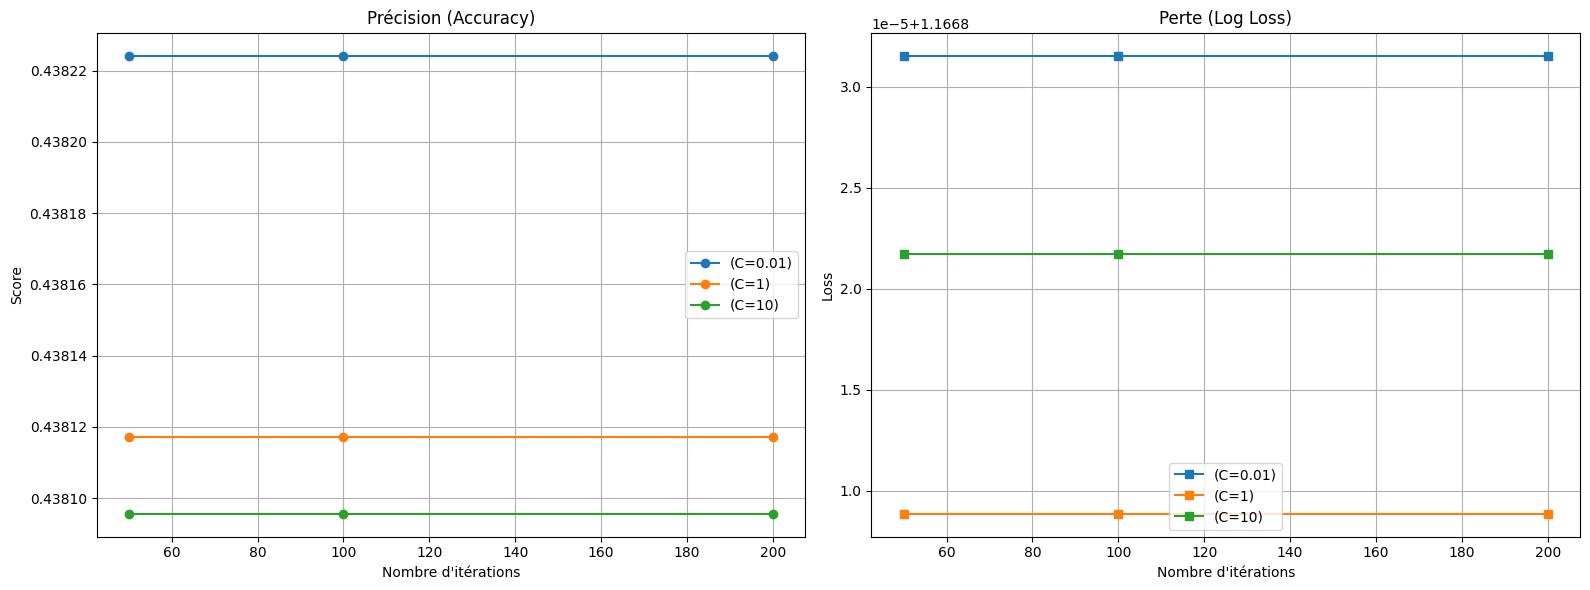

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

max_iters = [50, 100, 200]
c_values = [0.01, 1, 10]
solvers = []

results = []

print("Lancement du test comparatif...")


for c in c_values:
  acc_list = []
  loss_list = []

  for m_iter in max_iters:
    model = LogisticRegression(
        max_iter=m_iter,
        C=c,
        solver='newton-cg',
        class_weight='balanced',
        random_state=42
    )

    model.fit(x_train_scaled, y_train)

    acc = model.score(x_test_scaled, y_test)
    probs = model.predict_proba(x_test_scaled)
    loss = log_loss(y_test, probs)

    acc_list.append(acc)
    loss_list.append(loss)

    print(f"C={c} | Iterations ={m_iter} -> Accuracy: {acc:.4f} | Loss: {loss:.4f}")

  results.append({
      'label': f"(C={c})",
      'acc': acc_list,
      'loss': loss_list
  })

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for res in results:
    ax1.plot(max_iters, res['acc'], marker='o', label=res['label'])
    ax2.plot(max_iters, res['loss'], marker='s', label=res['label'])

ax1.set_title("Précision (Accuracy)")
ax1.set_xlabel("Nombre d'itérations")
ax1.set_ylabel("Score")
ax1.legend()
ax1.grid(True)

ax2.set_title("Perte (Log Loss)")
ax2.set_xlabel("Nombre d'itérations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Test -> Modèle : Profondeur: 50 | Samples: 50 | Score: 46.98% | Loss: 2.7366221444231287
Test -> Modèle : Profondeur: 100 | Samples: 50 | Score: 47.00% | Loss: 2.7362682939970235
Test -> Modèle : Profondeur: 50 | Samples: 100 | Score: 45.08% | Loss: 1.8975115629351347
Test -> Modèle : Profondeur: 100 | Samples: 100 | Score: 45.08% | Loss: 1.8975115629351347
Test -> Modèle : Profondeur: 50 | Samples: 1000 | Score: 43.61% | Loss: 1.2015188869072932
Test -> Modèle : Profondeur: 100 | Samples: 1000 | Score: 43.61% | Loss: 1.2015188869072932


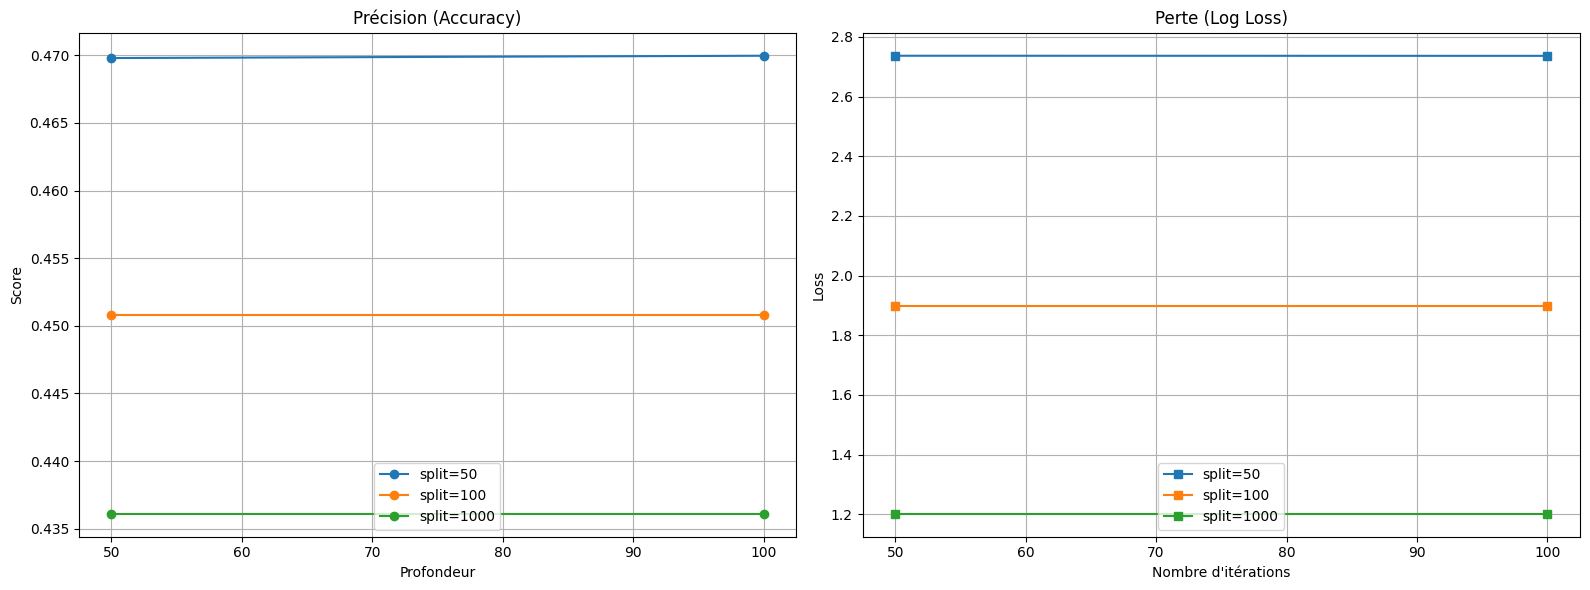

In [ ]:
depths = [50, 100]
min_samples = [50, 100, 1000]

results = []

for ms in min_samples:
  acc_list = []
  loss_list = []

  for d in depths:
    model = DecisionTreeClassifier(
        criterion='gini',
        max_depth=d,
        min_samples_split=ms,
        class_weight='balanced',
        random_state=42
    )
    model.fit(x_train, y_train)

    y_prob = model.predict_proba(x_test)
    y_pred = model.predict(x_test)

    loss = log_loss(y_test, y_prob)
    accuracy = accuracy_score(y_test, y_pred)

    acc_list.append(accuracy)
    loss_list.append(loss)
    print(f"Profondeur: {d} | Samples: {ms} | Score: {accuracy:.2%} | Loss: {loss}")

  results.append({
      'label': f"min_samples={ms}",
      'acc': acc_list,
      'loss': loss_list
  })

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for res in results:
    ax1.plot(depths, res['acc'], marker='o', label=res['label'])
    ax2.plot(depths, res['loss'], marker='s', label=res['label'])

ax1.set_title("Précision (Accuracy)")
ax1.set_xlabel("Profondeur")
ax1.set_ylabel("Score")
ax1.legend()
ax1.grid(True)

ax2.set_title("Perte (Log Loss)")
ax2.set_xlabel("Nombre d'itérations")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

On voit que les valeurs commencent à stagner autour d'une profondeur de 50 \
On constate qu'augmenter le nombre de min_samples ne fait pas tout, car la loss est très faible, mais l'accuracy aussi

Profondeur: 20 | Arbres: 50 | Score: 58.80% | Loss: 0.937
Profondeur: 20 | Arbres: 100 | Score: 59.29% | Loss: 0.9323
Profondeur: 20 | Arbres: 200 | Score: 59.49% | Loss: 0.9302
Profondeur: 100 | Arbres: 50 | Score: 62.56% | Loss: 0.9499
Profondeur: 100 | Arbres: 100 | Score: 63.04% | Loss: 0.8623
Profondeur: 100 | Arbres: 200 | Score: 63.32% | Loss: 0.8344


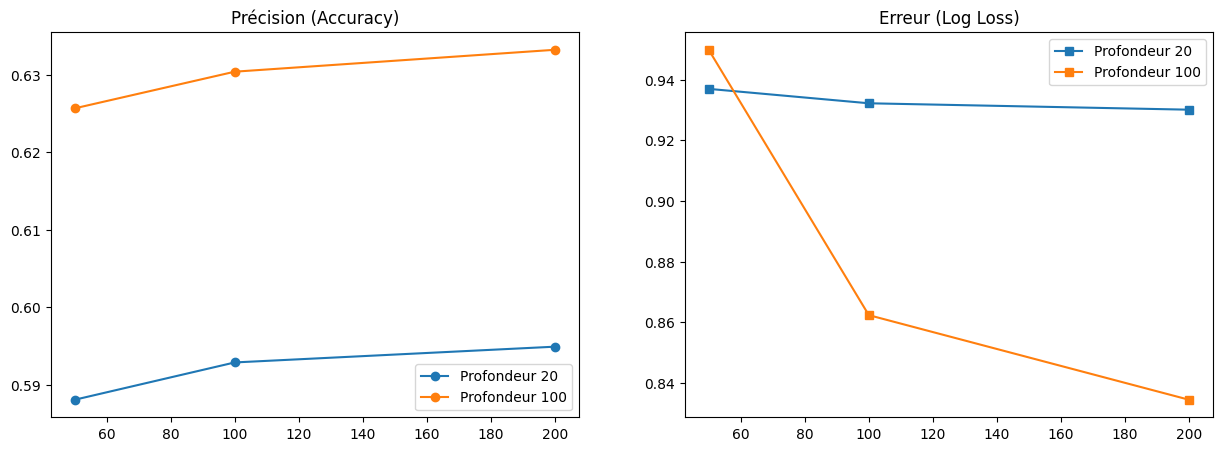

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss

nb_arbres = [50, 100, 200]
profondeurs = [20, 100]
results = []

for d in profondeurs:
  acc_par_step = []
  loss_par_step = []

  for n in nb_arbres:
    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=d,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    model.fit(x_train, y_train)

    preds = model.predict(x_test)
    probs = model.predict_proba(x_test)

    loss = log_loss(y_test, probs)
    accuracy = accuracy_score(y_test, preds)

    label_d = d if d is not None else "Max"
    print(f"Profondeur: {label_d} | Arbres: {n} | Score: {accuracy:.2%} | Loss: {loss:.4}")

    acc_par_step.append(accuracy)
    loss_par_step.append(loss)

  results.append({'depth': d, 'acc': acc_par_step, 'loss': loss_par_step})


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for res in results:
    nom = f"Profondeur {res['depth']}"
    ax1.plot(nb_arbres, res['acc'], '-o', label=nom)
    ax2.plot(nb_arbres, res['loss'], '-s', label=nom)

ax1.set_title("Précision (Accuracy)")
ax1.legend()
ax2.set_title("Erreur (Log Loss)")
ax2.legend()
plt.show()

On voit ici que les loss et accuracy stagnent à partir d'une profondeur de 100.
On remarque aussi que le nombre d'arbres utilisés améliore légèrement le résultat de nos tests

In [18]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(x_train.shape[1],)),
    tf.keras.layers.Dense(500, 'relu'),
    tf.keras.layers.Dense(1000, 'relu'),
    tf.keras.layers.Dense(500, 'relu'),
    tf.keras.layers.Dense(100, 'relu'),
    tf.keras.layers.Dense(10, 'relu'),
    tf.keras.layers.Dense(4, 'softmax'),
])

model.compile(
    optimizer = 'adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
model.summary()
history = model.fit(x_train, y_train, epochs = 1, validation_data = (x_test, y_test))
model.evaluate(x_test, y_test, verbose=2)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 500)            │        89,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1000)           │       501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        50,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            44 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,154 (4.36 MB)

 Trainable params: 1,142,154 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

4378/4378 ━━━━━━━━━━━━━━━━━━━━ 91s 20ms/step - accuracy: 0.4896 - loss: 0.9940 - val_accuracy: 0.5516 - val_loss: 0.9376
1460/1460 - 7s - 5ms/step - accuracy: 0.5516 - loss: 0.9376


[0.9375825524330139, 0.5516030192375183]

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Évolution de la précision')
plt.legend()

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Évolution de l\'erreur')
plt.legend()
plt.show()

### Avec regroupements (160 colonnes) :
[Loss, Accuracy]

LogisticRegression (lbfgs, c=0.01) : [1.17, 0.44]\
LogisticRegression (newton-cg, c=0.01) : [1.17, 0.44]\
DecisionTreeClassifier (Profondeur 50-100, min_samples 50-1000) :  [2.73-1.20,0.44-0.47]\
RandomForestClassifier (Profondeur 20-100, Nombre d'arbres 50-200) : [0.95-0.84, 0.46-0.63] \
Réseau de neurones : [0.93, 0.55]

Avec nos colonnes et optimisation actuelles, tous les modèles finissent par faire de l'overfitting (haute accuracy / faible loss en entraînement, accuracy moyenne / loss moyenne en test)